# Plot land carbon pool composition

In [1]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages())

Loading packages...


## Set parameters

In [2]:
#stat = 'integral'#'integral'#'mean'
#freq_input = 'monthly'#, 'yearly', 'daily'] #freq_output = 'monthly'#, 'yearly', 'daily', 'climatology', None]
varias = ['cLand','cSoil','cVeg','cCwd','cLitter'] # 'tas','tos',
models = ['IPSL-CM6-ESMCO2','GFDL-ESM2M','NorESM2-LM']#,'GISSE2.1-G-CC2','UKESM1-2','EC-Earth3-ESM-1']#[]#,
runs = pruns.get_run_list('tipmip_tier1')#[1:]
ref_year = 1

model_dict = pmods.get_model_dict('all')
run_dict = pruns.get_run_dict()

def get_freq_input(model):
    if model == 'GISSE2.1-G-CC2':
        freq_input = 'yearly'
    else:
        freq_input = 'monthly'
    return freq_input

## Convert time series

In [3]:
def convert_units(varia,stat,da):
    if varia == 'fgco2' and stat == 'integral' and da.units in ['kg m-2 s-1 x m2','kgC/m2/s x m2']:
        converter = 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    elif varia == 'nbp' and stat == 'integral' and da.units in ['kg m-2 s-1 x m2','kgC/m2/s x m2']:
        converter = 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    elif varia == 'intpp' and stat == 'integral' and da.units in ['mol m-2 s-1 x m2','mol/m2/s x m2']:
        converter = 12 * 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    elif varia == 'npp' and stat == 'integral' and da.units in ['kg m-2 s-1 x m2','kg/m2/s x m2']:
        converter = 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    elif varia == 'cLand' and stat == 'integral' and da.units in ['kg m-2 x m2','kg/m2 x m2']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'cSoil' and stat == 'integral' and da.units in ['kg m-2 x m2','kg/m2 x m2']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'cVeg' and stat == 'integral' and da.units in ['kg m-2 x m2','kg/m2 x m2']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'cCwd' and stat == 'integral' and da.units in ['kg m-2 x m2','kg/m2 x m2']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'cLitter' and stat == 'integral' and da.units in ['kg m-2 x m2','kg/m2 x m2']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    else:
        da_conv = da
    return da_conv

def get_stat(varia,default=True):
    if default == True:
        if varia in ['tas','tos']:
            stat = 'mean'
        elif varia in ['fgco2','intpp','nbp','npp','cLand','cSoil','cVeg','cCwd','cLitter']:
            stat = 'integral'
    else:
        stat = 'mean'
    return stat

## Load and plot individual models, yearly means (and monthly means if available)

In [4]:
def get_time_series(model,varia):
    freq_input = get_freq_input(model)
    stat = get_stat(varia)
    mgrab = MODELgrabber.get_grabber(model)
    member = mgrab.get_member()
    #color = model_dict[model].color_id
    global_stats = dict() 
    for run in runs:
        try:
            color = run_dict[run].color_id
            # get the data
            load_dir = f'./../01_postprocessed_data/global_time_series/{varia}/{model}/{run}/{member}/{freq_input}/global_{stat}'
            load_string = f'{load_dir}/{varia}_{model}_{run}_{member}_global_{stat}.nc'
            global_stat = xr.open_dataset(load_string,use_cftime=True)
            global_stat = global_stat[f"{varia}_global_{stat}"]
            # convert
            global_stat = convert_units(varia,stat,global_stat)
            # put into dictionary
            global_stats[run] = global_stat
        except:
            print(f'Nothing to plot for {varia}, {model}, {member}, {run}, {freq_input}, global {stat}.')
    return global_stats

In [5]:
global_stats = dict()
for model in models:
    global_stats[model] = dict()
    for varia in varias:
        global_stats[model][varia] = get_time_series(model,varia)


Nothing to plot for cCwd, IPSL-CM6-ESMCO2, r1i2p3f1, esm-piControl, monthly, global integral.
Nothing to plot for cCwd, IPSL-CM6-ESMCO2, r1i2p3f1, esm-up2p0, monthly, global integral.
Nothing to plot for cCwd, IPSL-CM6-ESMCO2, r1i2p3f1, esm-up2p0-gwl2p0, monthly, global integral.
Nothing to plot for cCwd, IPSL-CM6-ESMCO2, r1i2p3f1, esm-up2p0-gwl4p0, monthly, global integral.
Nothing to plot for cCwd, IPSL-CM6-ESMCO2, r1i2p3f1, esm-up2p0-gwl2p0-50y-dn2p0, monthly, global integral.
Nothing to plot for cCwd, IPSL-CM6-ESMCO2, r1i2p3f1, esm-up2p0-gwl4p0-50y-dn2p0, monthly, global integral.
Nothing to plot for cCwd, IPSL-CM6-ESMCO2, r1i2p3f1, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0, monthly, global integral.
Nothing to plot for cLitter, IPSL-CM6-ESMCO2, r1i2p3f1, esm-piControl, monthly, global integral.
Nothing to plot for cLitter, IPSL-CM6-ESMCO2, r1i2p3f1, esm-up2p0, monthly, global integral.
Nothing to plot for cLitter, IPSL-CM6-ESMCO2, r1i2p3f1, esm-up2p0-gwl2p0, monthly, global integral.
Noth

Nothing to plot for cLitter, IPSL-CM6-ESMCO2, r1i2p3f1, esm-piControl, monthly, global integral.
Nothing to plot for cLitter, IPSL-CM6-ESMCO2, r1i2p3f1, esm-piControl, monthly, global integral.
Nothing to plot for cLitter, IPSL-CM6-ESMCO2, r1i2p3f1, esm-up2p0, monthly, global integral.
Nothing to plot for cLitter, IPSL-CM6-ESMCO2, r1i2p3f1, esm-up2p0, monthly, global integral.
Nothing to plot for cLitter, IPSL-CM6-ESMCO2, r1i2p3f1, esm-up2p0-gwl2p0, monthly, global integral.
Nothing to plot for cLitter, IPSL-CM6-ESMCO2, r1i2p3f1, esm-up2p0-gwl2p0, monthly, global integral.
Nothing to plot for cLitter, IPSL-CM6-ESMCO2, r1i2p3f1, esm-up2p0-gwl4p0, monthly, global integral.
Nothing to plot for cLitter, IPSL-CM6-ESMCO2, r1i2p3f1, esm-up2p0-gwl4p0, monthly, global integral.
Nothing to plot for cLitter, IPSL-CM6-ESMCO2, r1i2p3f1, esm-up2p0-gwl2p0-50y-dn2p0, monthly, global integral.
Nothing to plot for cLitter, IPSL-CM6-ESMCO2, r1i2p3f1, esm-up2p0-gwl2p0-50y-dn2p0, monthly, global integral.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Nothing to plot for cLitter, IPSL-CM6-ESMCO2, r1i2p3f1, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0, monthly, global integral.
Nothing to plot for cLitter, IPSL-CM6-ESMCO2, r1i2p3f1, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0, monthly, global integral.


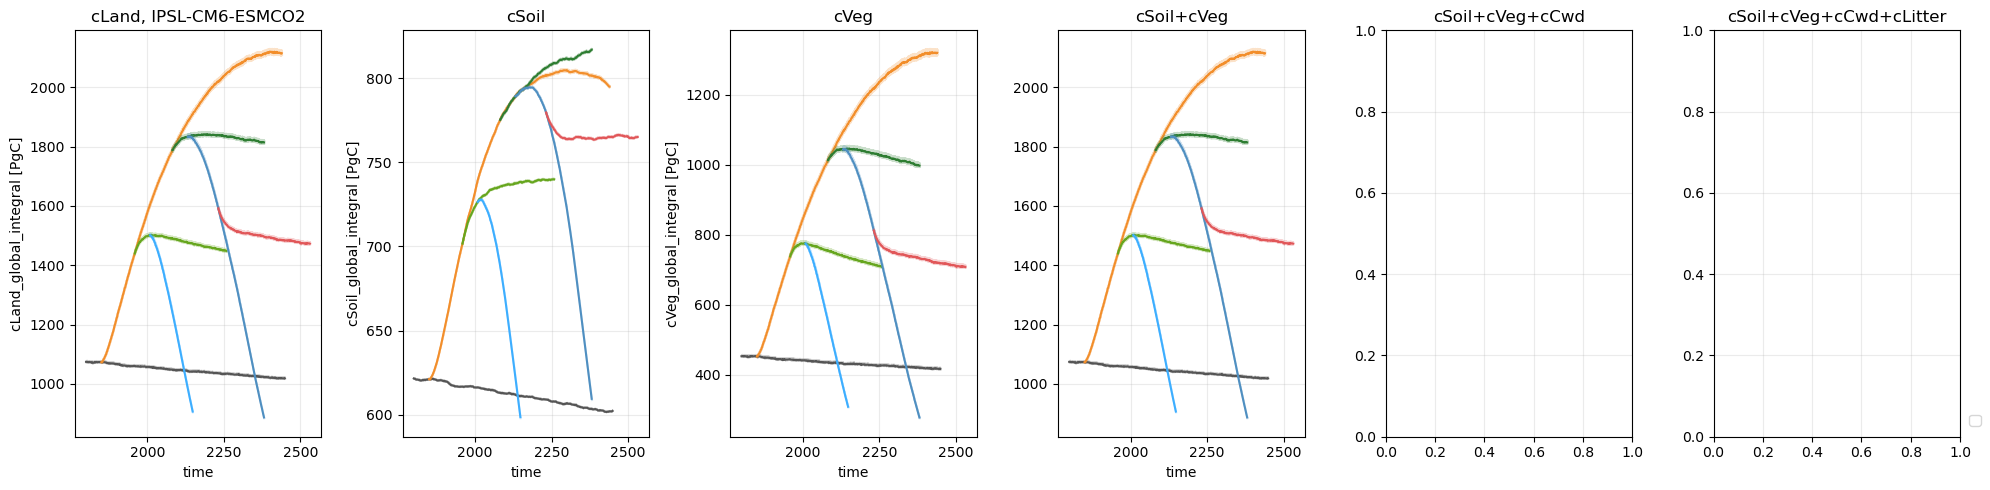

Nothing to plot for cLitter, GFDL-ESM2M, r1i1p1f1, esm-piControl, monthly, global integral.
Nothing to plot for cLitter, GFDL-ESM2M, r1i1p1f1, esm-piControl, monthly, global integral.
Nothing to plot for cLitter, GFDL-ESM2M, r1i1p1f1, esm-up2p0, monthly, global integral.
Nothing to plot for cLitter, GFDL-ESM2M, r1i1p1f1, esm-up2p0, monthly, global integral.
Nothing to plot for cLitter, GFDL-ESM2M, r1i1p1f1, esm-up2p0-gwl2p0, monthly, global integral.
Nothing to plot for cLitter, GFDL-ESM2M, r1i1p1f1, esm-up2p0-gwl2p0, monthly, global integral.
Nothing to plot for cLitter, GFDL-ESM2M, r1i1p1f1, esm-up2p0-gwl4p0, monthly, global integral.
Nothing to plot for cLitter, GFDL-ESM2M, r1i1p1f1, esm-up2p0-gwl4p0, monthly, global integral.
Nothing to plot for cLitter, GFDL-ESM2M, r1i1p1f1, esm-up2p0-gwl2p0-50y-dn2p0, monthly, global integral.
Nothing to plot for cLitter, GFDL-ESM2M, r1i1p1f1, esm-up2p0-gwl2p0-50y-dn2p0, monthly, global integral.
Nothing to plot for cLitter, GFDL-ESM2M, r1i1p1f1,

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Nothing to plot for cLitter, GFDL-ESM2M, r1i1p1f1, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0, monthly, global integral.
Nothing to plot for cLitter, GFDL-ESM2M, r1i1p1f1, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0, monthly, global integral.


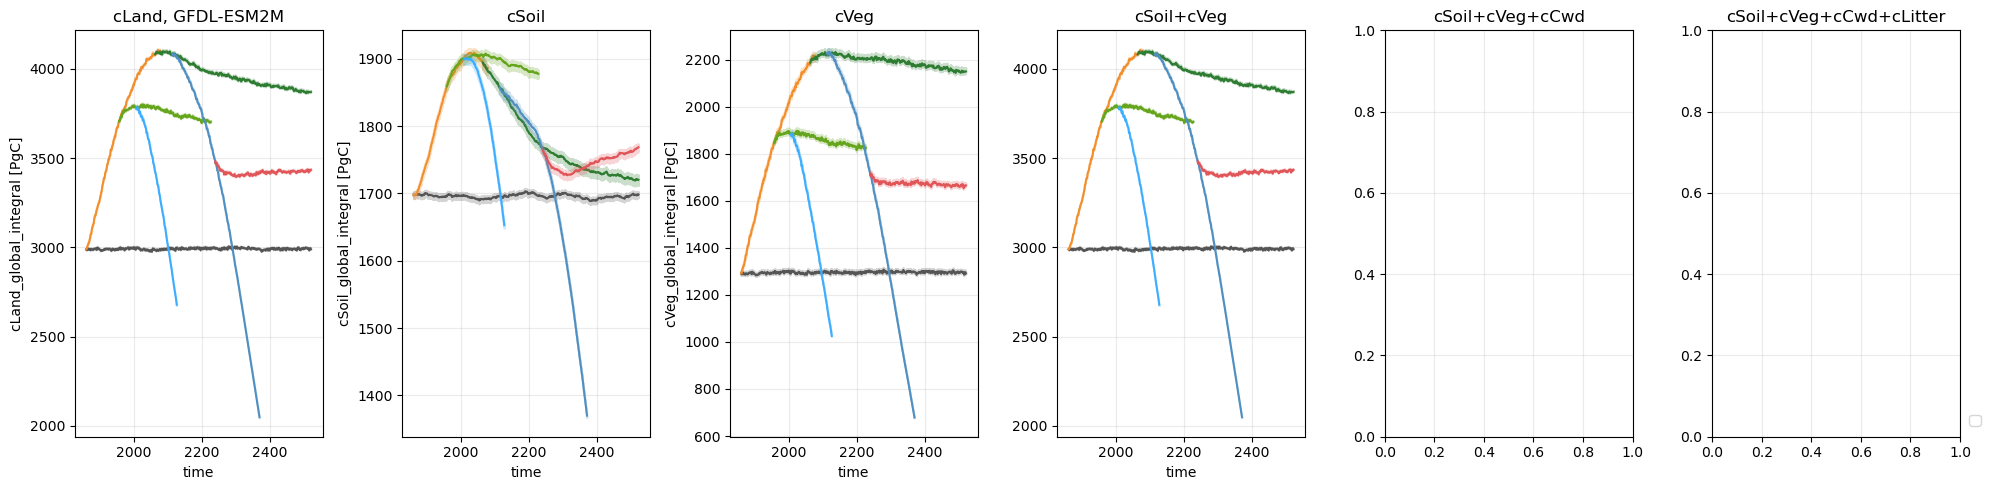

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


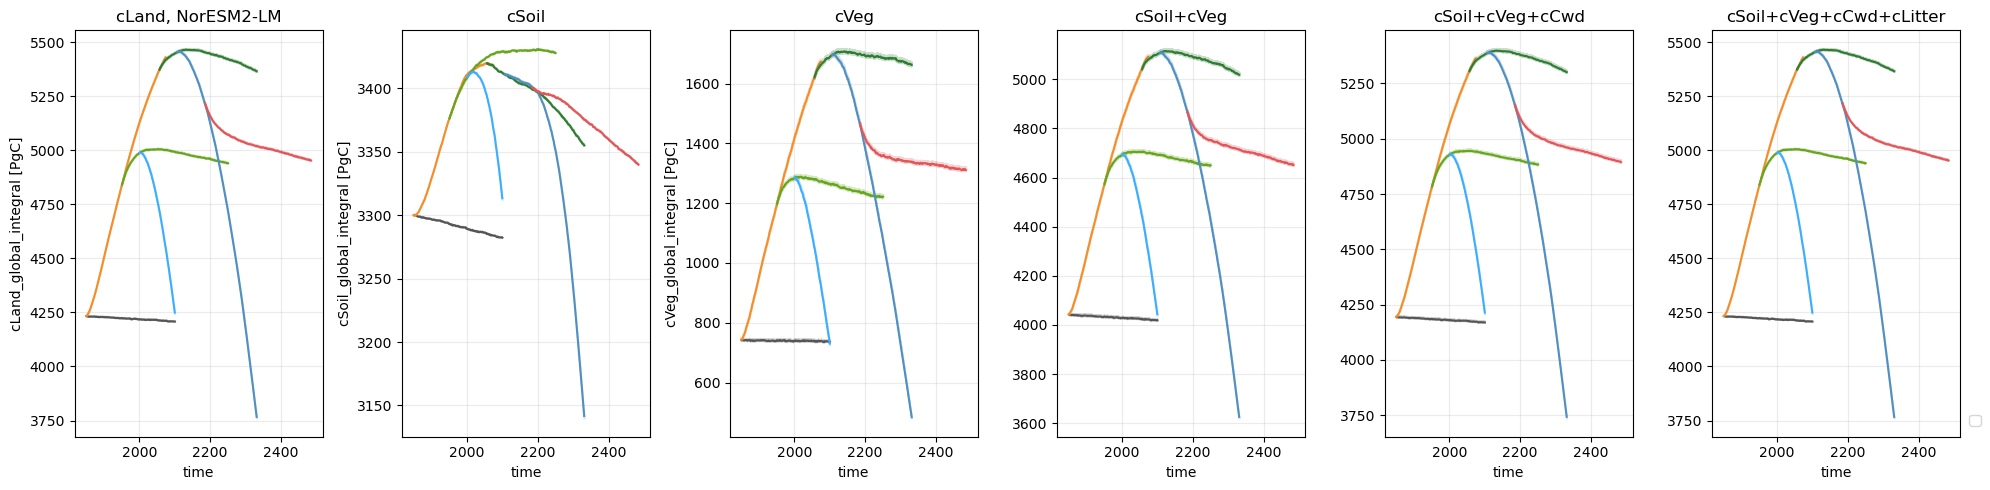

In [6]:
for model in models:
    freq_input = get_freq_input(model)
    stat = get_stat(varia)
    mgrab = MODELgrabber.get_grabber(model)
    member = mgrab.get_member()

    fig, ax = plt.subplots(1,6,figsize=(20,5))
    for run in runs:
    
        try:
            color = run_dict[run].color_id
            global_stats[model]['cLand'][run].plot(alpha=0.25,color=color,ax=ax[0])
            global_stats[model]['cLand'][run].resample(time="1YS").mean().plot(alpha=1,color=color,ax=ax[0],label=run)
            
            soilc = global_stats[model]['cSoil'][run]
            vegc = global_stats[model]['cVeg'][run]
            
            soilc.plot(alpha=0.25,color=color,ax=ax[1])
            soilc.resample(time="1YS").mean().plot(alpha=1,color=color,ax=ax[1])
            
            vegc.plot(alpha=0.25,color=color,ax=ax[2])
            vegc.resample(time="1YS").mean().plot(alpha=1,color=color,ax=ax[2])
            
            (soilc+vegc).plot(alpha=0.25,color=color,ax=ax[3])
            (soilc+vegc).resample(time="1YS").mean().plot(alpha=1,color=color,ax=ax[3])

        except:
            print(f'Nothing to plot for {varia}, {model}, {member}, {run}, {freq_input}, global {stat}.')


        try:
            Cwdc = global_stats[model]['cCwd'][run]
            (soilc+vegc+Cwdc).plot(alpha=0.25,color=color,ax=ax[4])
            (soilc+vegc+Cwdc).resample(time="1YS").mean().plot(alpha=1,color=color,ax=ax[4])
        except:
            print(f'Nothing to plot for {varia}, {model}, {member}, {run}, {freq_input}, global {stat}.')

        try:
            litterc = global_stats[model]['cLitter'][run]
            (soilc+vegc+Cwdc+litterc).plot(alpha=0.25,color=color,ax=ax[5])
            (soilc+vegc+Cwdc+litterc).resample(time="1YS").mean().plot(alpha=1,color=color,ax=ax[5])
        except:
            print(f'Nothing to plot for {varia}, {model}, {member}, {run}, {freq_input}, global {stat}.')

    ax[0].set_title(f'cLand, {model}')
    ax[1].set_title(f'cSoil')
    ax[2].set_title(f'cVeg')
    ax[3].set_title(f'cSoil+cVeg')
    ax[4].set_title(f'cSoil+cVeg+cCwd')
    ax[5].set_title(f'cSoil+cVeg+cCwd+cLitter')
    for axi in ax:
        axi.grid(alpha=0.25)
    plt.subplots_adjust(right=0.8)
    plt.legend(loc='lower left',bbox_to_anchor=(1.01,0.01))
    plt.tight_layout()
    plt.show()

Nothing to plot for cLitter, IPSL-CM6-ESMCO2, r1i1p1f1, esm-piControl, monthly, global integral.
Nothing to plot for cLitter, IPSL-CM6-ESMCO2, r1i1p1f1, esm-piControl, monthly, global integral.
Nothing to plot for cLitter, IPSL-CM6-ESMCO2, r1i1p1f1, esm-up2p0, monthly, global integral.
Nothing to plot for cLitter, IPSL-CM6-ESMCO2, r1i1p1f1, esm-up2p0, monthly, global integral.
Nothing to plot for cLitter, IPSL-CM6-ESMCO2, r1i1p1f1, esm-up2p0-gwl2p0, monthly, global integral.
Nothing to plot for cLitter, IPSL-CM6-ESMCO2, r1i1p1f1, esm-up2p0-gwl2p0, monthly, global integral.
Nothing to plot for cLitter, IPSL-CM6-ESMCO2, r1i1p1f1, esm-up2p0-gwl4p0, monthly, global integral.
Nothing to plot for cLitter, IPSL-CM6-ESMCO2, r1i1p1f1, esm-up2p0-gwl4p0, monthly, global integral.
Nothing to plot for cLitter, IPSL-CM6-ESMCO2, r1i1p1f1, esm-up2p0-gwl2p0-50y-dn2p0, monthly, global integral.
Nothing to plot for cLitter, IPSL-CM6-ESMCO2, r1i1p1f1, esm-up2p0-gwl2p0-50y-dn2p0, monthly, global integral.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Nothing to plot for cLitter, IPSL-CM6-ESMCO2, r1i1p1f1, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0, monthly, global integral.
Nothing to plot for cLitter, IPSL-CM6-ESMCO2, r1i1p1f1, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0, monthly, global integral.


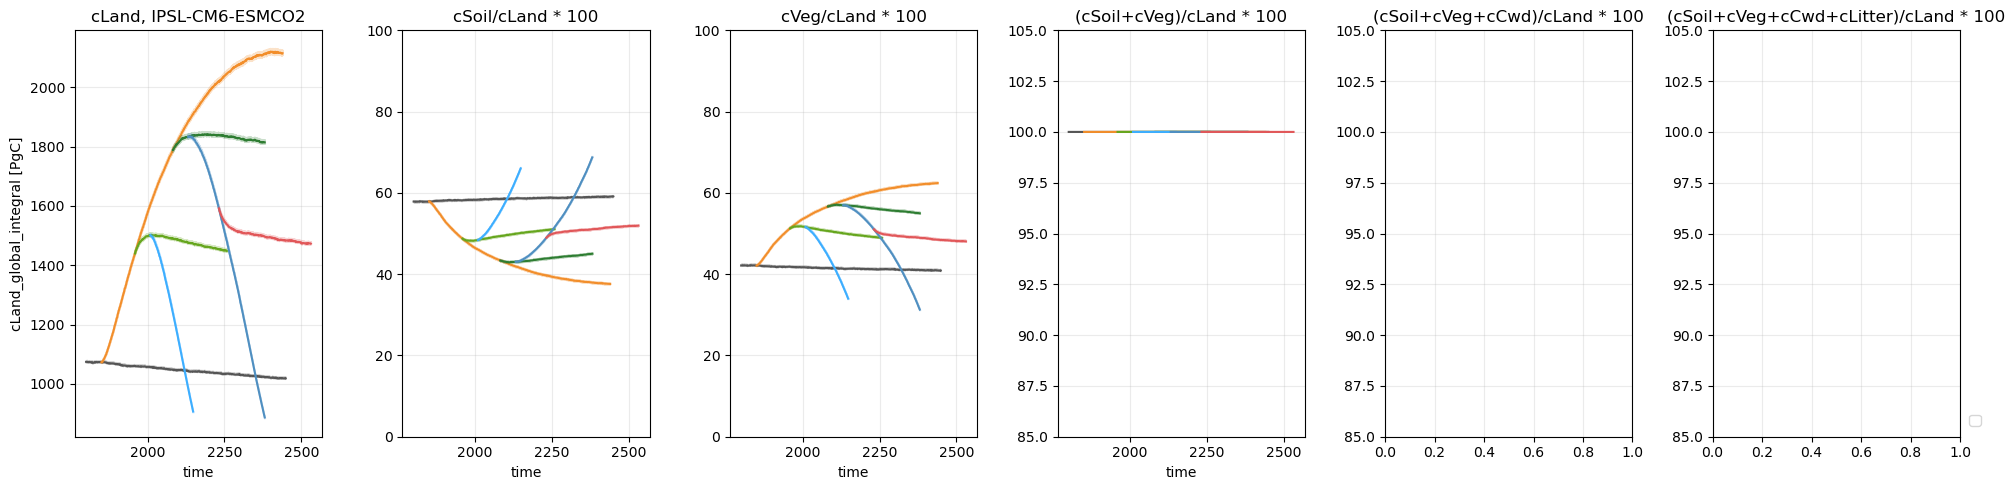

Nothing to plot for cLitter, GFDL-ESM2M, r1i1p1f1, esm-piControl, monthly, global integral.
Nothing to plot for cLitter, GFDL-ESM2M, r1i1p1f1, esm-piControl, monthly, global integral.
Nothing to plot for cLitter, GFDL-ESM2M, r1i1p1f1, esm-up2p0, monthly, global integral.
Nothing to plot for cLitter, GFDL-ESM2M, r1i1p1f1, esm-up2p0, monthly, global integral.
Nothing to plot for cLitter, GFDL-ESM2M, r1i1p1f1, esm-up2p0-gwl2p0, monthly, global integral.
Nothing to plot for cLitter, GFDL-ESM2M, r1i1p1f1, esm-up2p0-gwl2p0, monthly, global integral.
Nothing to plot for cLitter, GFDL-ESM2M, r1i1p1f1, esm-up2p0-gwl4p0, monthly, global integral.
Nothing to plot for cLitter, GFDL-ESM2M, r1i1p1f1, esm-up2p0-gwl4p0, monthly, global integral.
Nothing to plot for cLitter, GFDL-ESM2M, r1i1p1f1, esm-up2p0-gwl2p0-50y-dn2p0, monthly, global integral.
Nothing to plot for cLitter, GFDL-ESM2M, r1i1p1f1, esm-up2p0-gwl2p0-50y-dn2p0, monthly, global integral.
Nothing to plot for cLitter, GFDL-ESM2M, r1i1p1f1,

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Nothing to plot for cLitter, GFDL-ESM2M, r1i1p1f1, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0, monthly, global integral.
Nothing to plot for cLitter, GFDL-ESM2M, r1i1p1f1, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0, monthly, global integral.


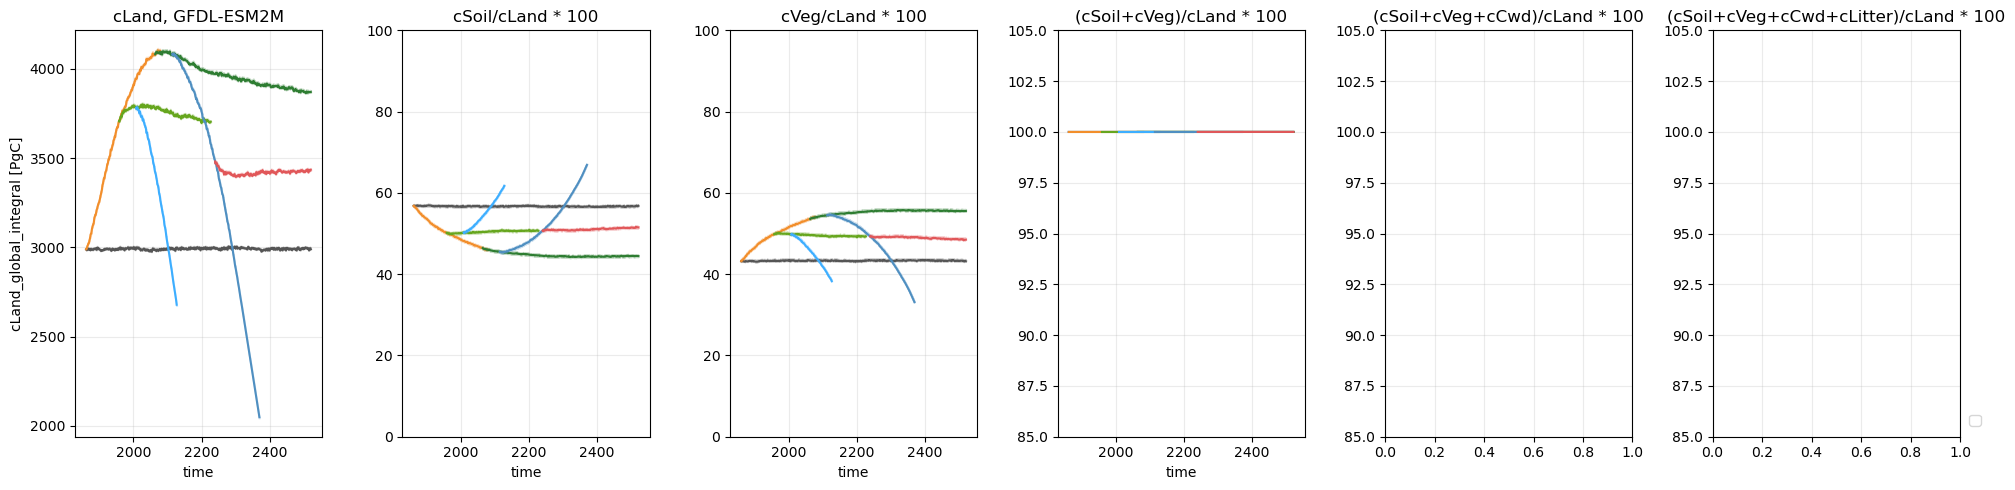

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


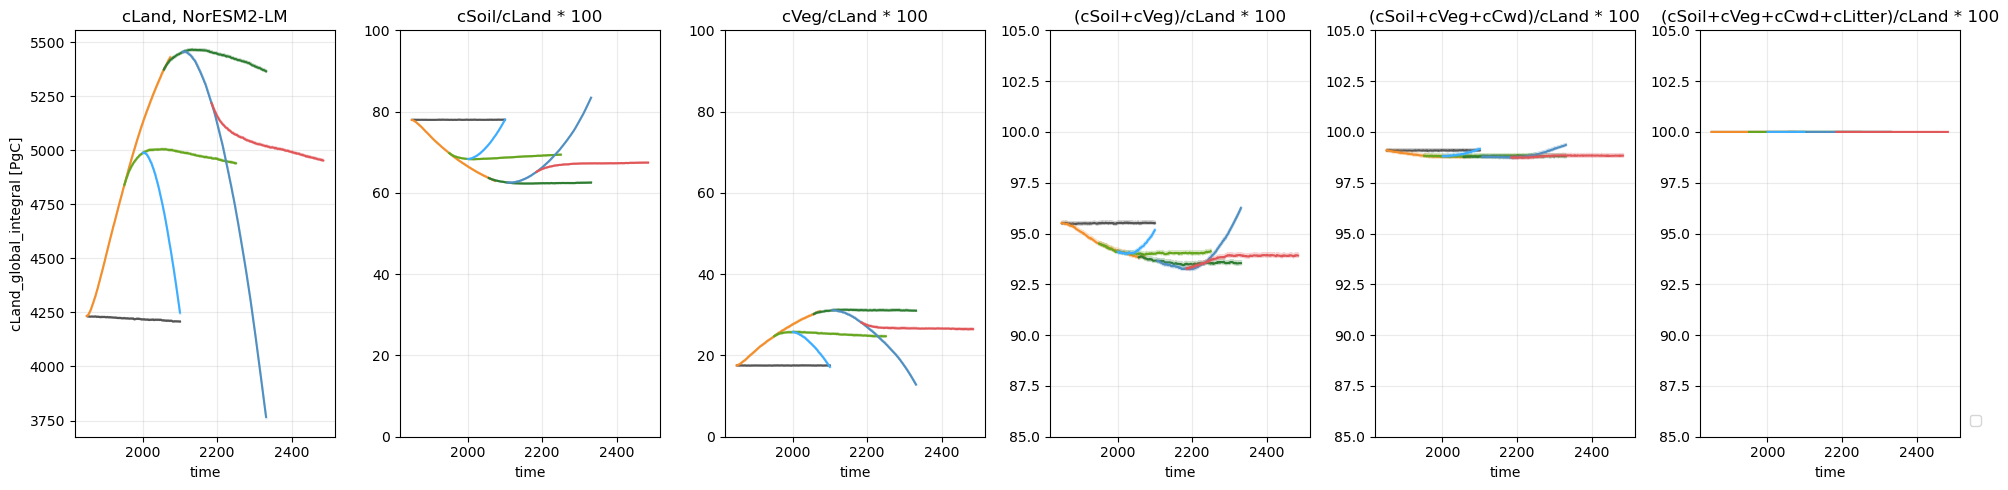

In [10]:
for model in models:
    fig, ax = plt.subplots(1,6,figsize=(20,5))
    for run in runs:
        try:
            color = run_dict[run].color_id
            global_stats[model]['cLand'][run].plot(alpha=0.25,color=color,ax=ax[0])
            global_stats[model]['cLand'][run].resample(time="1YS").mean().plot(alpha=1,color=color,ax=ax[0],label=run)
            
            soilfrac = global_stats[model]['cSoil'][run]/global_stats[model]['cLand'][run]*100
            vegfrac = global_stats[model]['cVeg'][run]/global_stats[model]['cLand'][run]*100
            
            soilfrac.plot(alpha=0.25,color=color,ax=ax[1])
            soilfrac.resample(time="1YS").mean().plot(alpha=1,color=color,ax=ax[1])
            
            vegfrac.plot(alpha=0.25,color=color,ax=ax[2])
            vegfrac.resample(time="1YS").mean().plot(alpha=1,color=color,ax=ax[2])
            
            (soilfrac+vegfrac).plot(alpha=0.25,color=color,ax=ax[3])
            (soilfrac+vegfrac).resample(time="1YS").mean().plot(alpha=1,color=color,ax=ax[3])
        except:
            print(f'Nothing to plot for {varia}, {model}, {member}, {run}, {freq_input}, global {stat}.')

        try:
            Cwdfrac = global_stats[model]['cCwd'][run]/global_stats[model]['cLand'][run]*100
            (soilfrac+vegfrac+Cwdfrac).plot(alpha=0.25,color=color,ax=ax[4])
            (soilfrac+vegfrac+Cwdfrac).resample(time="1YS").mean().plot(alpha=1,color=color,ax=ax[4])
        except:
            print(f'Nothing to plot for {varia}, {model}, {member}, {run}, {freq_input}, global {stat}.')

        try:
            litterfrac = global_stats[model]['cLitter'][run]/global_stats[model]['cLand'][run]*100
            (soilfrac+vegfrac+Cwdfrac+litterfrac).plot(alpha=0.25,color=color,ax=ax[5])
            (soilfrac+vegfrac+Cwdfrac+litterfrac).resample(time="1YS").mean().plot(alpha=1,color=color,ax=ax[5])
        except:
            print(f'Nothing to plot for {varia}, {model}, {member}, {run}, {freq_input}, global {stat}.')
    
    ax[0].set_title(f'cLand, {model}')
    ax[1].set_title(f'cSoil/cLand * 100')
    ax[2].set_title(f'cVeg/cLand * 100')
    ax[3].set_title(f'(cSoil+cVeg)/cLand * 100')
    ax[4].set_title(f'(cSoil+cVeg+cCwd)/cLand * 100')
    ax[5].set_title(f'(cSoil+cVeg+cCwd+cLitter)/cLand * 100')
    for axi in ax:
        axi.grid(alpha=0.25)
    for axi in ax[1:-2]:
        axi.set_ylim([0,100])
    for axi in ax[-3:]:
        axi.set_ylim([85,105])
    plt.subplots_adjust(right=0.8)
    plt.legend(loc='lower left',bbox_to_anchor=(1.01,0.01))
    plt.tight_layout()
    plt.show()